In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from src.models.model import LitS4Model
from src.data.data import LitDataModule
from src.utils.plotting import *
import torch
from torch.utils.data import DataLoader
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import tqdm
import numpy as np
import yaml
from scipy import signal

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = '/n/home03/creissel/neutrino_project/runs/combined_ts_inputIQ_iterativeTraining_withUnc/Project8/309u0qua/'
CHECKPOINT = os.path.join(path, 'checkpoints/last.ckpt')
image_folder = os.path.join(path, 'results')

In [3]:
! mkdir "{image_folder}"

In [4]:
model = LitS4Model.load_from_checkpoint(CHECKPOINT)
model = model.to(device)
model = model.eval()

ArgumentError: Parser key "module":
  Does not validate against any of the Union subtypes
  Subtypes: [<class 'NoneType'>, <class 'src.models.model.LitS4Model'>]
  Errors:
    - Expected a <class 'NoneType'>
    - Import path src.models.model.LitS4CombinedModel does not correspond to a subclass of LitS4Model
  Given value type: <class 'dict'>
  Given value: {'class_path': 'src.models.model.LitS4CombinedModel', 'dict_kwargs': {'lambda_denoise': 1.0, 'lambda_regress': 1.0, 'lambda_denoise_schedule': None, 'lambda_regress_schedule': {'schedule_type': 'step', 'step_schedule': [[0, 0.0], [30, 0.5], [60, 1.0]]}, 'trainer_max_epochs': 80, 'denoising_loss': 'MixtureMSESpectralLoss', 'denoising_weights': None, 'denoising_huber_delta': 1.0, 'denoising_spectral_alpha': 0.5, 'encoder': {'class_path': 'src.models.networks.S4DCombinedModel', 'init_args': {'d_input': 2, 'd_output': 4, 'denoiser_d_model': 128, 'denoiser_n_layers': 6, 'denoiser_dropout': 0.0, 'denoiser_prenorm': False, 'denoiser_gradie

In [10]:
dataset = LitDataModule.load_from_checkpoint(CHECKPOINT)

In [11]:
true = []
pred = []
meta = []

max_powers = []
summed_powers = []

for ts,fft,var,obs in dataset.test_dataloader():
    with torch.no_grad():
        pred.append(model(fft.to(device)).cpu().numpy())
        true.append(var.numpy())
        meta.append(obs.numpy())

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/torch/nn/functional.py:1381: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-wise "


In [12]:
#true = np.concatenate(true)
#pred = np.concatenate(pred)

true = np.concatenate(true, axis=0)
pred = np.concatenate(pred, axis=0)
meta = np.concatenate(meta, axis=0)

In [13]:
# undo the normalization
pred_post = pred * dataset.stds + dataset.mu
true_post = true * dataset.stds + dataset.mu

/n/home03/creissel/neutrino_project/runs/s4d_ts_dmodel128_layers6_lr1e-3_comparison/Project8/k7qm6dyt/results


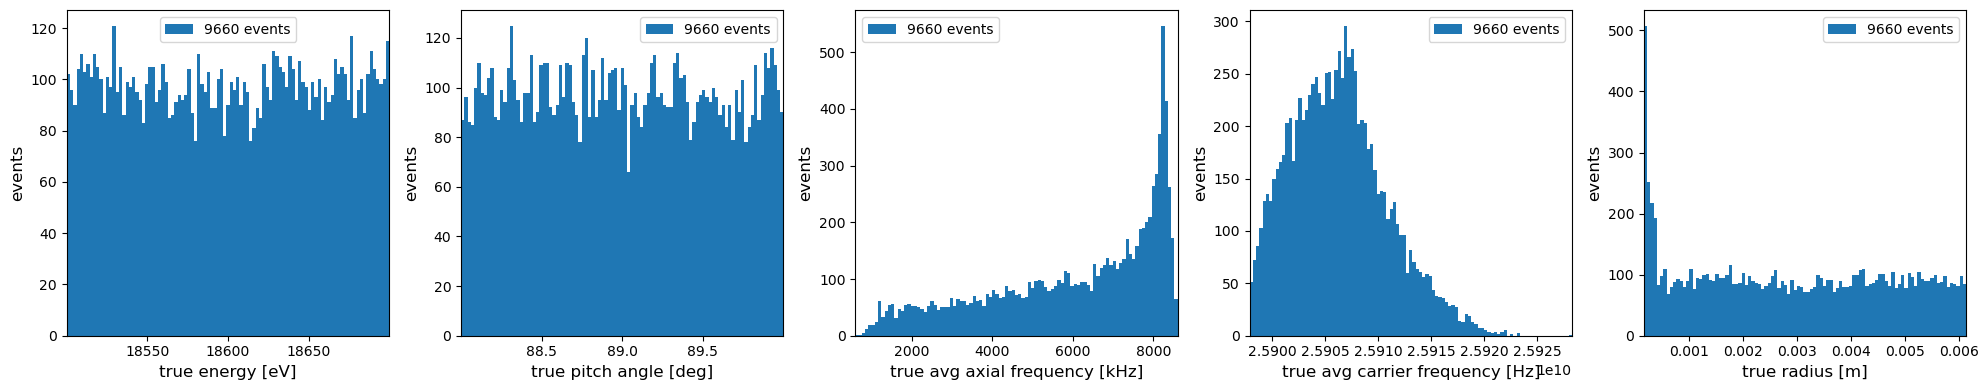

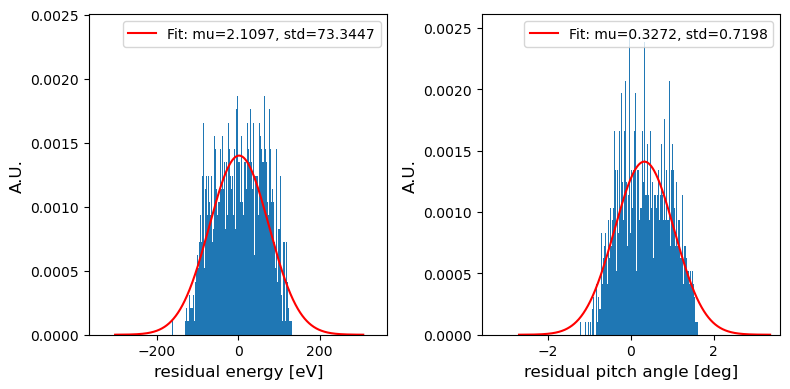

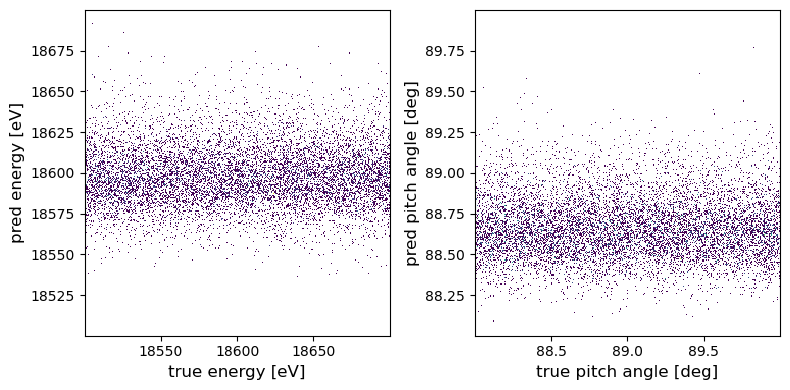

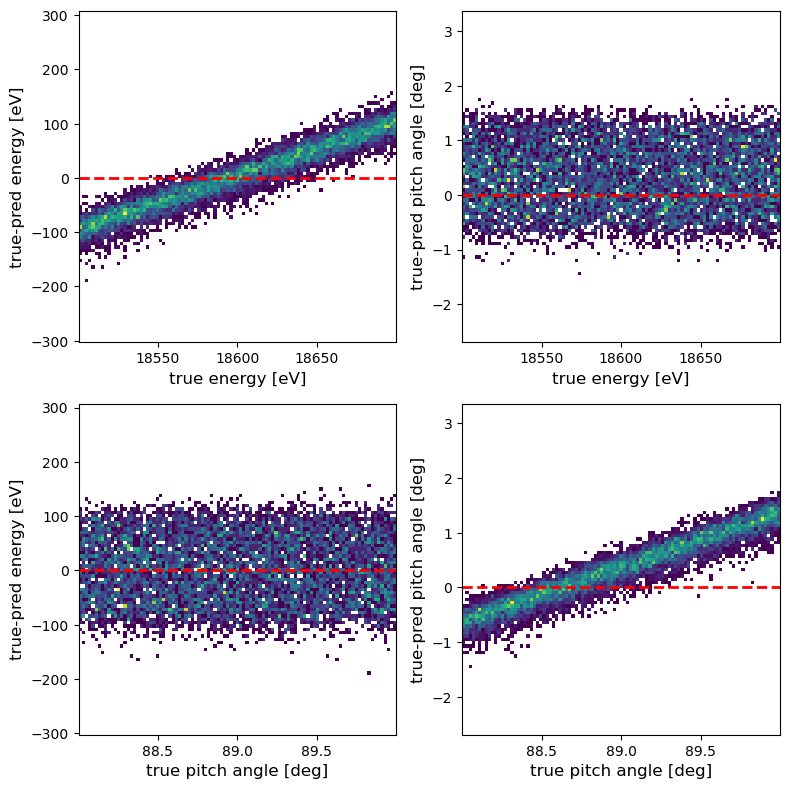

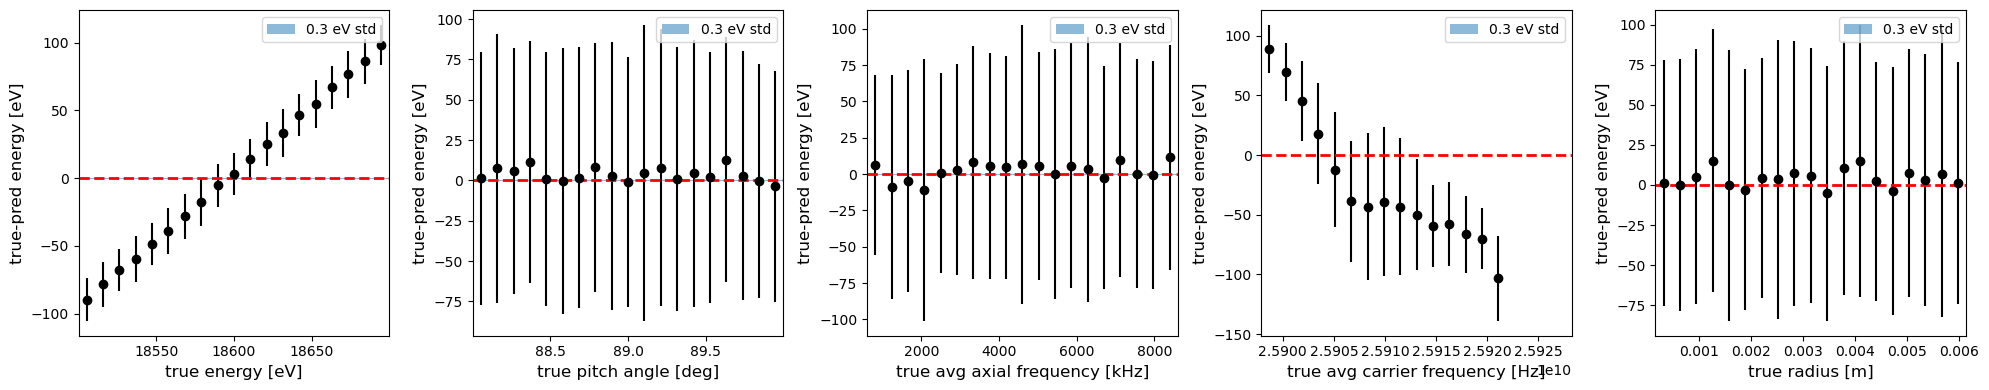

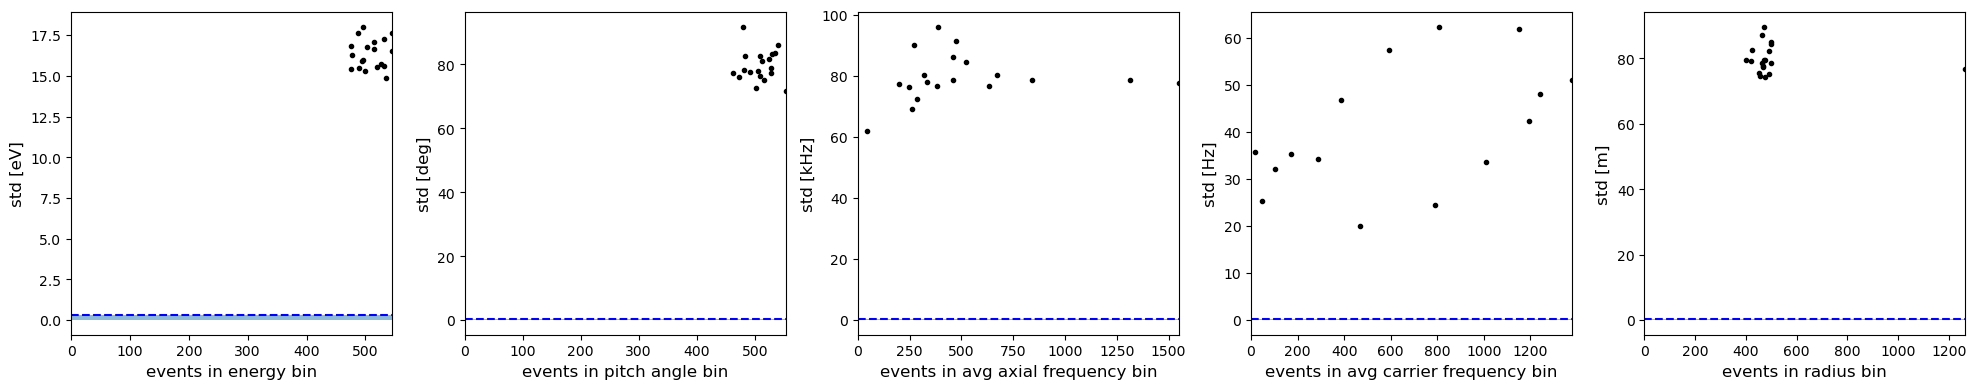

In [14]:
f = make_all_plots(dataset.variables, dataset.observables,true_post, pred_post, meta, folder=image_folder, savefigs=True)

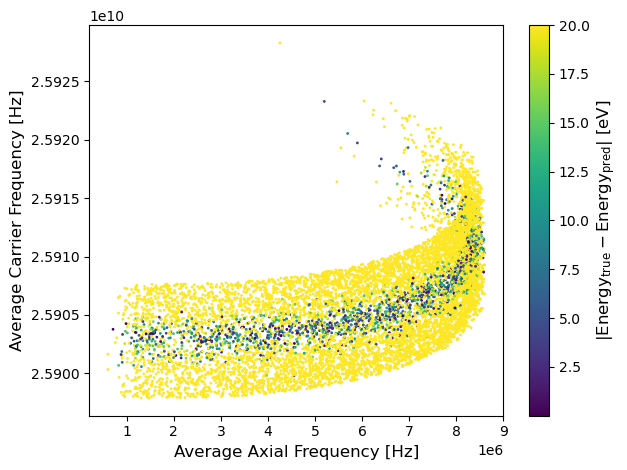

In [15]:
# true, pred: energy_eV, pitch_angle_deg
# meta: avg_axial_frequency_Hz, avg_carrier_frequency_Hz, radius_m

avg_axial_frequency_Hz = meta[:, 0]
avg_carrier_frequency_Hz = meta[:, 1]
true_energy = true_post[:, 0]
pred_energy = pred_post[:, 0]

fig, ax = plt.subplots()

sc = ax.scatter(
    avg_axial_frequency_Hz,
    avg_carrier_frequency_Hz,
    c=np.abs(true_energy - pred_energy),
    s=1,
    cmap='viridis', 
    vmax=20
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$|\text{Energy}_{\text{true}} - \text{Energy}_{\text{pred}}|$ [eV]")

plt.xlabel("Average Axial Frequency [Hz]")
plt.ylabel("Average Carrier Frequency [Hz]")

plt.tight_layout()
plt.show()
